# 04 Quotes Full C+D `<1B>` Closeout

Notebook de cierre de `quotes/v2`.

Este notebook no explora ni recalcula. Solo consume la cache final `<1B>` y deja una lectura ejecutiva de cierre.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from IPython.display import Markdown, clear_output, display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)

ROOT = Path(r"C:/TSIS_Data/02_backtest_SmallCaps")
CACHE_ROOT = Path(r"C:/Users/AlexJ/.codex/memories/backtest_SmallCaps/quotes_cd_notebook_cache_v2")
MANIFEST_PATH = CACHE_ROOT / "manifest_cd_lt1b.json"
PROGRESS_PATH = CACHE_ROOT / "build_progress_cd_lt1b.json"
TARGET_LT1B_PATH = ROOT / "runs/backtest/market_cap_last_observed_cutoff/20260320_market_cap_last_observed_cutoff/market_cap_cutoff_lt_1b_active_inactive.parquet"

ARTIFACTS = {
    'snapshot': CACHE_ROOT / 'snapshot_cd_lt1b.parquet',
    'severity': CACHE_ROOT / 'severity_counts_cd_lt1b.parquet',
    'root_mix': CACHE_ROOT / 'root_mix_cd_lt1b.parquet',
    'taxonomy_summary': CACHE_ROOT / 'taxonomy_summary_cd_lt1b.parquet',
    'case_index': CACHE_ROOT / 'case_index_top50_cd_lt1b.parquet',
    'timestamp_view': CACHE_ROOT / 'timestamp_view_cd_lt1b.parquet',
    'hard_issue_counts': CACHE_ROOT / 'hard_issue_counts_cd_lt1b.parquet',
    'warn_counts': CACHE_ROOT / 'warn_counts_cd_lt1b.parquet',
    'crossed_gap_severity_summary': CACHE_ROOT / 'crossed_gap_severity_summary_cd_lt1b.parquet',
    'crossed_gap_severity_cases': CACHE_ROOT / 'crossed_gap_severity_cases_cd_lt1b.parquet',
    'positive_cross_review_summary': CACHE_ROOT / 'positive_cross_review_summary_cd_lt1b.parquet',
    'positive_cross_review_cases': CACHE_ROOT / 'positive_cross_review_cases_cd_lt1b.parquet',
}

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
progress = json.loads(PROGRESS_PATH.read_text(encoding='utf-8'))

def load_artifact(name: str) -> pd.DataFrame:
    return pd.read_parquet(ARTIFACTS[name])


## Preflight De Artefactos

Esta celda valida que el notebook abierto y el kernel estan viendo la version correcta de `ARTIFACTS` y de la cache `v2`.


In [2]:
REQUIRED_ARTIFACT_KEYS = [
    'crossed_gap_severity_summary',
    'crossed_gap_severity_cases',
    'positive_cross_review_summary',
    'positive_cross_review_cases',
]

missing_keys = [k for k in REQUIRED_ARTIFACT_KEYS if k not in ARTIFACTS]
missing_files = [k for k in REQUIRED_ARTIFACT_KEYS if k in ARTIFACTS and not Path(ARTIFACTS[k]).exists()]

if missing_keys or missing_files:
    raise RuntimeError({
        'missing_keys_in_ARTIFACTS': missing_keys,
        'missing_files_on_disk': missing_files,
        'hint': 'Reabre el notebook actualizado, reinicia el kernel y ejecuta otra vez desde la primera celda.'
    })

display(pd.DataFrame([
    {
        'artifact_key': k,
        'path': str(ARTIFACTS[k]),
        'exists': Path(ARTIFACTS[k]).exists(),
        'size_bytes': int(Path(ARTIFACTS[k]).stat().st_size),
    }
    for k in REQUIRED_ARTIFACT_KEYS
]))

,artifact_key,path,exists,size_bytes
0,crossed_gap_severity_summary,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\crossed_gap_severity_summary_cd_lt1b.p...,True,21678
1,crossed_gap_severity_cases,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\crossed_gap_severity_cases_cd_lt1b.par...,True,99056
2,positive_cross_review_summary,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\positive_cross_review_summary_cd_lt1b....,True,9210
3,positive_cross_review_cases,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\positive_cross_review_cases_cd_lt1b.pa...,True,40019


## Alcance Auditado

Este cierre resume la auditoria del merged `quotes_current_cd_merged`, restringida por ticker al universo canonico `<1B>` usado tambien en `trades`.


In [3]:
snapshot = load_artifact('snapshot')
severity = load_artifact('severity')
root_mix = load_artifact('root_mix')

scope_df = pd.DataFrame([
    {
        'source_parquet': manifest['source_parquet'],
        'row_count_source_full': manifest['row_count_source_full'],
        'target_lt1b_path': manifest['target_lt1b_path'],
        'target_lt1b_tickers': manifest['target_lt1b_tickers'],
        'snapshot_rows_total_lt1b': int(snapshot.iloc[0]['rows_total']),
        'snapshot_ticker_n_lt1b': int(snapshot.iloc[0]['ticker_n']),
        'snapshot_date_min': str(snapshot.iloc[0]['date_min']),
        'snapshot_date_max': str(snapshot.iloc[0]['date_max']),
        'progress_status': progress.get('status'),
        'elapsed_sec_last_taxonomy_run': progress.get('elapsed_sec'),
    }
])
display(scope_df)


,source_parquet,row_count_source_full,target_lt1b_path,target_lt1b_tickers,snapshot_rows_total_lt1b,snapshot_ticker_n_lt1b,snapshot_date_min,snapshot_date_max,progress_status,elapsed_sec_last_taxonomy_run
0,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_v2_materialized\quotes_current_cd_merged\quotes_current.parquet,9930334,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\market_cap_last_observed_cutoff\20260320_market_cap_last_observed_c...,4824,9525272,4822,2005-01-03,2026-03-20,completed,0.32


## Resumen de Severidad

Primero fijamos la mezcla global `PASS / SOFT_FAIL / HARD_FAIL` y el reparto por root.


,severity,files,pct
0,PASS,4365496,45.830670
1,SOFT_FAIL,4078384,42.816457
2,HARD_FAIL,1081392,11.352873


,root,PASS,SOFT_FAIL,HARD_FAIL,total,pass_pct,soft_fail_pct,hard_fail_pct
0,C,789616,754266,223600,1767482,44.674628,42.674607,12.650765
1,D,3575880,3324118,857792,7757790,46.094055,42.848775,11.057170


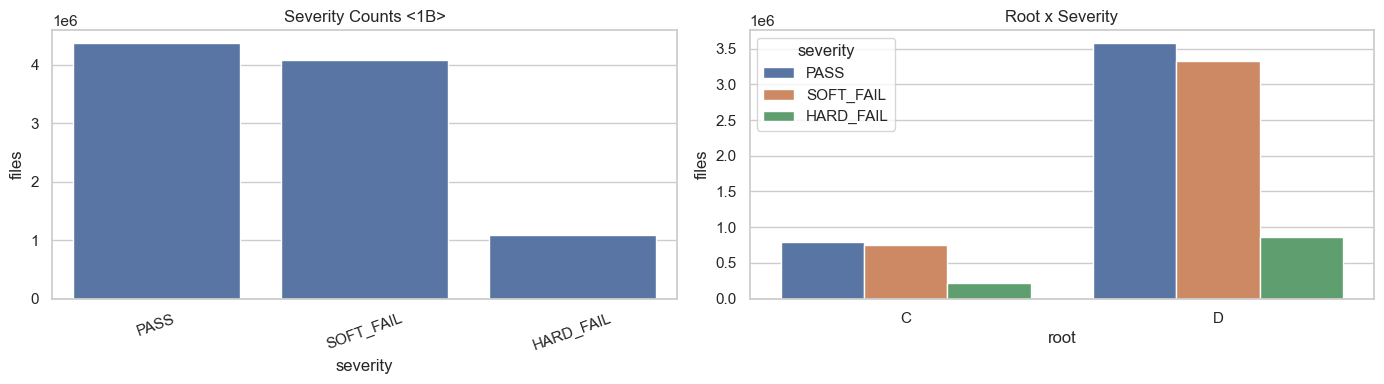

In [4]:
display(severity)
display(root_mix)

root_mix_long = root_mix.melt(
    id_vars=['root'],
    value_vars=['PASS', 'SOFT_FAIL', 'HARD_FAIL'],
    var_name='severity',
    value_name='files',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=severity, x='severity', y='files', ax=axes[0], order=severity.sort_values('files', ascending=False)['severity'])
axes[0].set_title('Severity Counts <1B>')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=root_mix_long, x='root', y='files', hue='severity', ax=axes[1])
axes[1].set_title('Root x Severity')
plt.tight_layout()


## Taxonomia Final

Esta es la taxonomia final de cierre tras las dos vueltas de refinamiento sobre `quotes <1B>`.


,taxonomy,files,tickers,dates,hard_fail_files,soft_fail_files,crossed_ratio_median_pct,crossed_ratio_p90_pct,pct
0,clean_pass_or_other,4361934,4815,5337,0,0,0.000000,0.000000,45.793275
1,soft_crossed_micro_noise,1924034,4611,5336,0,1924034,0.032744,0.080386,20.199255
2,persistent_soft_crossed_low,887600,4776,5335,0,887600,0.168634,0.265588,9.318369
3,persistent_soft_crossed_mid_thin_scale,558372,4722,5335,0,558372,0.472144,0.714286,5.862006
4,utc_rollover_large_day_clean,542446,4639,1729,0,542446,0.000000,0.051120,5.694809
5,small_file_threshold_edge_hard,321772,3246,5332,321772,0,2.380952,4.255319,3.378087
6,medium_file_threshold_edge_hard_few_crosses,220181,3947,5333,220181,0,1.238390,2.659574,2.311546
7,high_hard_crossed_5_to_20,168534,3241,5328,168534,0,6.666667,9.090909,1.769335
8,utc_rollover_large_day_with_soft_crossed,118856,4491,1757,0,118856,0.221029,0.550756,1.247796
9,high_hard_crossed_10_to_20,101549,2572,5300,101549,0,13.043478,17.647059,1.066101


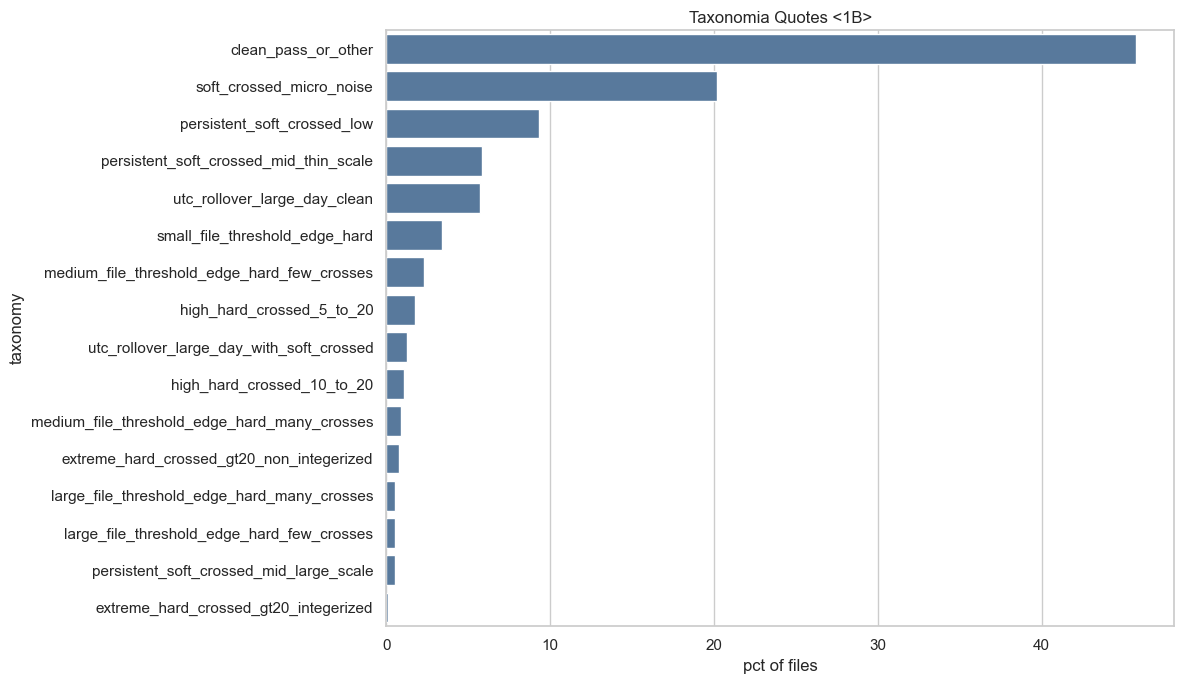

In [5]:
taxonomy = load_artifact('taxonomy_summary')
display(taxonomy)

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = taxonomy.sort_values('pct', ascending=False).head(16)
sns.barplot(data=plot_df, y='taxonomy', x='pct', ax=ax, color='#4C78A8')
ax.set_title('Taxonomia Quotes <1B>')
ax.set_xlabel('pct of files')
ax.set_ylabel('taxonomy')
plt.tight_layout()


## Residuo Bajo Revision

No todo el residuo tiene el mismo peso operativo. Estos buckets concentran la parte que merece lectura manual final.


,taxonomy,files,tickers,dates,hard_fail_files,soft_fail_files,crossed_ratio_median_pct,crossed_ratio_p90_pct,pct
9,high_hard_crossed_10_to_20,101549,2572,5300,101549,0,13.043478,17.647059,1.066101
10,medium_file_threshold_edge_hard_many_crosses,85963,3871,5320,85963,0,2.020202,4.156712,0.902473
12,large_file_threshold_edge_hard_many_crosses,50288,2828,4819,50288,0,1.522505,3.638552,0.527943
14,persistent_soft_crossed_mid_large_scale,47076,2615,4544,0,47076,0.435341,0.682123,0.494222


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_37532\983363712.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_df, y='taxonomy', x='pct', ax=ax, palette='magma')


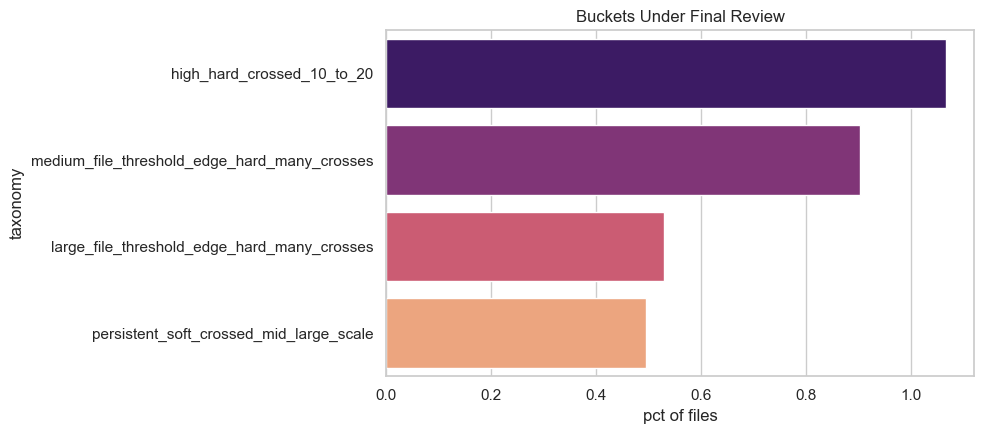

In [6]:
review_buckets = [
    'persistent_soft_crossed_mid_large_scale',
    'large_file_threshold_edge_hard_many_crosses',
    'medium_file_threshold_edge_hard_many_crosses',
    'high_hard_crossed_10_to_20',
]
review_df = taxonomy[taxonomy['taxonomy'].isin(review_buckets)].copy().sort_values('pct', ascending=False)
display(review_df)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=review_df, y='taxonomy', x='pct', ax=ax, palette='magma')
ax.set_title('Buckets Under Final Review')
ax.set_xlabel('pct of files')
plt.tight_layout()


## Severidad economica del crossed

Aqui dejamos de mirar solo `crossed_ratio_pct` y pasamos a medir la magnitud del cruce cuando `bid_price > ask_price`.

Metricas:

- `cross_abs = bid_price - ask_price`
- `cross_rel_bps = (bid_price - ask_price) / mid_price * 10000`
- si `cross_rel_bps` se va hacia `20000`, normalmente estamos viendo `ask_price = 0` o cuasi `0`, no un microcruce pequeno alrededor del spread


,taxonomy,sample_files,sample_tickers,crossed_ratio_pct_median,crossed_ratio_pct_p90,cross_abs_median,cross_abs_p90,cross_rel_bps_median,cross_rel_bps_p90,crossed_ask_zero_share_pct_median,crossed_ask_positive_share_pct_median,cross_abs_median_ask_positive,cross_abs_p90_ask_positive,cross_rel_bps_median_ask_positive,cross_rel_bps_p90_ask_positive,near_zero_share_pct_median,mild_share_pct_median,moderate_share_pct_median,severe_share_pct_median,near_zero_share_pct_ask_positive_median,mild_share_pct_ask_positive_median,moderate_share_pct_ask_positive_median,severe_share_pct_ask_positive_median,crossed_rows_raw_total,crossed_rows_ask_zero_total,crossed_rows_ask_positive_total,crossed_area_abs_total
0,extreme_integerized_100pct_crossed,40,33,100.000000,100.000000,6.92000,19.9800,20000.000000,20000.0,100.000000,0.000000,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,100.000000,NaN,NaN,NaN,NaN,292,292,0,2108.3250
1,extreme_hard_crossed_gt20_integerized,40,31,59.687500,85.714286,6.97000,26.7810,20000.000000,20000.0,100.000000,0.000000,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,100.000000,NaN,NaN,NaN,NaN,361,361,0,5536.7382
2,extreme_hard_crossed_gt20_non_integerized,40,40,31.250000,60.666667,6.44500,24.9704,20000.000000,20000.0,100.000000,0.000000,0.00525,0.00921,51.472676,87.063605,0.0,0.000000,0.000000,100.000000,0.0,8.196721,23.770492,68.032787,1405,1321,84,24048.9492
3,high_hard_crossed_10_to_20,40,38,13.245614,18.750000,9.14500,19.1800,20000.000000,20000.0,100.000000,0.000000,0.17500,0.29900,127.118183,199.508701,0.0,0.000000,0.000000,100.000000,0.0,0.000000,16.666667,83.333333,1062,1054,8,16087.8084
4,high_hard_crossed_5_to_20,40,39,6.666667,8.660287,9.79750,19.8131,20000.000000,20000.0,100.000000,0.000000,0.14000,0.23300,82.407026,163.018526,0.0,0.000000,0.000000,100.000000,0.0,0.000000,12.890625,87.109375,338,209,129,1583.1301
5,small_file_threshold_edge_hard,40,39,2.667141,4.357488,6.48000,21.1610,20000.000000,20000.0,100.000000,0.000000,0.01010,0.01802,27.816412,279.508019,0.0,0.000000,0.000000,100.000000,0.0,0.000000,0.000000,100.000000,60,56,4,525.2402
6,medium_file_threshold_edge_hard_many_crosses,40,40,2.041282,4.232808,9.32250,30.7596,20000.000000,20000.0,100.000000,0.000000,0.01000,0.03800,18.885741,362.047154,0.0,0.000000,0.000000,100.000000,0.0,0.000000,30.000000,0.000000,428,318,110,4803.2164
7,large_file_threshold_edge_hard_many_crosses,40,39,1.598421,3.578138,0.03000,37.8350,10057.471264,20000.0,52.069257,47.930743,0.01000,0.08200,10.025063,181.783889,0.0,0.000000,3.589025,94.769022,0.0,0.403226,41.250000,1.470588,7564,2126,5438,44618.7132
8,medium_file_threshold_edge_hard_few_crosses,40,40,1.207287,1.924076,2.07000,18.0730,20000.000000,20000.0,100.000000,0.000000,0.01000,0.02000,69.248881,202.784552,0.0,0.000000,0.000000,100.000000,0.0,0.000000,0.000000,100.000000,114,90,24,813.0554
9,large_file_threshold_edge_hard_few_crosses,40,38,1.140327,2.131850,0.02500,24.4130,81.396629,20000.0,14.000000,86.000000,0.01000,0.08500,27.587458,243.379078,0.0,0.000000,0.000000,100.000000,0.0,0.000000,25.000000,69.047619,1064,513,551,6909.4418


,taxonomy,sample_files,sample_tickers,crossed_ratio_pct_median,crossed_ratio_pct_p90,cross_abs_median,cross_abs_p90,cross_rel_bps_median,cross_rel_bps_p90,crossed_ask_zero_share_pct_median,crossed_ask_positive_share_pct_median,cross_abs_median_ask_positive,cross_abs_p90_ask_positive,cross_rel_bps_median_ask_positive,cross_rel_bps_p90_ask_positive,near_zero_share_pct_median,mild_share_pct_median,moderate_share_pct_median,severe_share_pct_median,near_zero_share_pct_ask_positive_median,mild_share_pct_ask_positive_median,moderate_share_pct_ask_positive_median,severe_share_pct_ask_positive_median,crossed_rows_raw_total,crossed_rows_ask_zero_total,crossed_rows_ask_positive_total,crossed_area_abs_total
3,high_hard_crossed_10_to_20,40,38,13.245614,18.750000,9.1450,19.1800,20000.000000,20000.0,100.000000,0.000000,0.175,0.299,127.118183,199.508701,0.0,0.000000,0.000000,100.000000,0.0,0.000000,16.666667,83.333333,1062,1054,8,16087.8084
6,medium_file_threshold_edge_hard_many_crosses,40,40,2.041282,4.232808,9.3225,30.7596,20000.000000,20000.0,100.000000,0.000000,0.010,0.038,18.885741,362.047154,0.0,0.000000,0.000000,100.000000,0.0,0.000000,30.000000,0.000000,428,318,110,4803.2164
7,large_file_threshold_edge_hard_many_crosses,40,39,1.598421,3.578138,0.0300,37.8350,10057.471264,20000.0,52.069257,47.930743,0.010,0.082,10.025063,181.783889,0.0,0.000000,3.589025,94.769022,0.0,0.403226,41.250000,1.470588,7564,2126,5438,44618.7132
10,persistent_soft_crossed_mid_large_scale,40,39,0.462518,0.598974,0.0100,4.2820,7.199700,20000.0,0.000000,100.000000,0.010,0.074,6.251954,75.392661,0.0,10.465116,45.169946,3.083804,0.0,21.428571,46.153846,2.531646,7627,252,7375,6062.5441


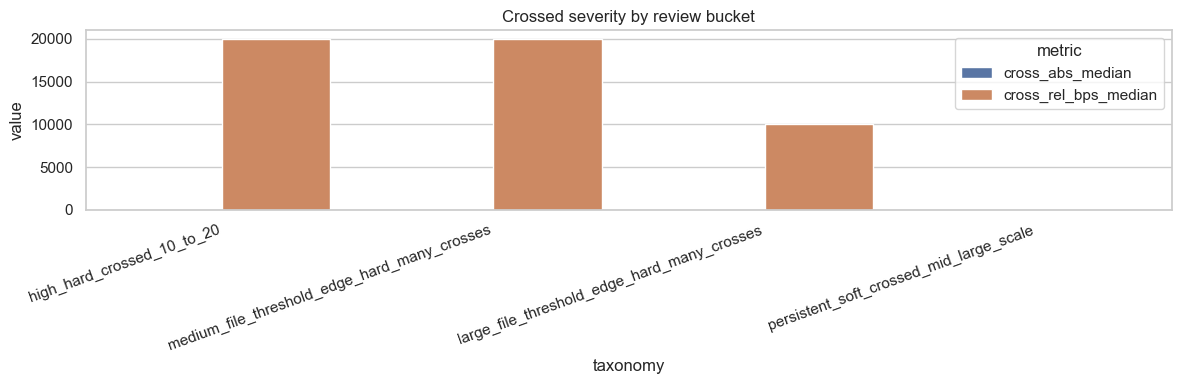

In [7]:
cross_gap = load_artifact('crossed_gap_severity_summary')
display(cross_gap.sort_values('sample_files', ascending=False))

focus_gap = cross_gap[cross_gap['taxonomy'].isin([
    'persistent_soft_crossed_mid_large_scale',
    'large_file_threshold_edge_hard_many_crosses',
    'medium_file_threshold_edge_hard_many_crosses',
    'high_hard_crossed_10_to_20',
])].copy()

display(focus_gap.sort_values('cross_rel_bps_median', ascending=False))

plot_df = focus_gap.melt(
    id_vars=['taxonomy'],
    value_vars=['cross_abs_median', 'cross_rel_bps_median'],
    var_name='metric',
    value_name='value',
)

plt.figure(figsize=(12, 4))
sns.barplot(data=plot_df, x='taxonomy', y='value', hue='metric')
plt.xticks(rotation=20, ha='right')
plt.title('Crossed severity by review bucket')
plt.tight_layout()

## Regimenes de crossed positivo

Esta seccion separa los buckets mixtos por severidad del crossed con `ask > 0`.

Regla:

- `mild`: `< 5 bps`
- `moderate`: `5-25 bps`
- `severe`: `>= 25 bps`


,taxonomy,positive_cross_bucket,sample_files,sample_tickers,crossed_ask_zero_share_pct_median,crossed_ask_positive_share_pct_median,cross_rel_bps_median_ask_positive,cross_rel_bps_p90_ask_positive,mild_share_pct_ask_positive_median,moderate_share_pct_ask_positive_median,severe_share_pct_ask_positive_median
0,high_hard_crossed_10_to_20,positive_cross_severe_ge25bps,2,2,83.797654,16.202346,127.118183,199.508701,0.000000,16.666667,83.333333
1,large_file_threshold_edge_hard_many_crosses,positive_cross_severe_ge25bps,6,6,0.000000,100.000000,70.542038,257.124140,0.000000,8.097643,88.335870
2,large_file_threshold_edge_hard_many_crosses,positive_cross_moderate_5to25bps,11,11,0.581395,99.418605,11.133791,40.080160,0.000000,99.193548,0.215517
3,large_file_threshold_edge_hard_many_crosses,positive_cross_mild_lt5bps,8,7,0.000000,100.000000,1.624225,11.390784,71.781581,17.082578,0.155119
4,medium_file_threshold_edge_hard_many_crosses,positive_cross_severe_ge25bps,5,5,0.000000,100.000000,108.108108,543.682154,0.000000,0.000000,100.000000
5,medium_file_threshold_edge_hard_many_crosses,positive_cross_moderate_5to25bps,3,3,0.000000,100.000000,18.885741,34.434043,0.000000,100.000000,0.000000
6,medium_file_threshold_edge_hard_many_crosses,positive_cross_mild_lt5bps,5,5,9.090909,90.909091,3.312904,13.372251,70.000000,30.000000,0.000000
7,persistent_soft_crossed_mid_large_scale,positive_cross_severe_ge25bps,5,5,0.000000,100.000000,39.395929,197.889438,0.000000,33.333333,66.666667
8,persistent_soft_crossed_mid_large_scale,positive_cross_moderate_5to25bps,18,17,0.000000,100.000000,9.446338,56.106254,0.000000,84.828010,8.666667
9,persistent_soft_crossed_mid_large_scale,positive_cross_mild_lt5bps,16,16,0.747126,99.252874,3.062431,19.540298,85.345648,11.735331,0.000000


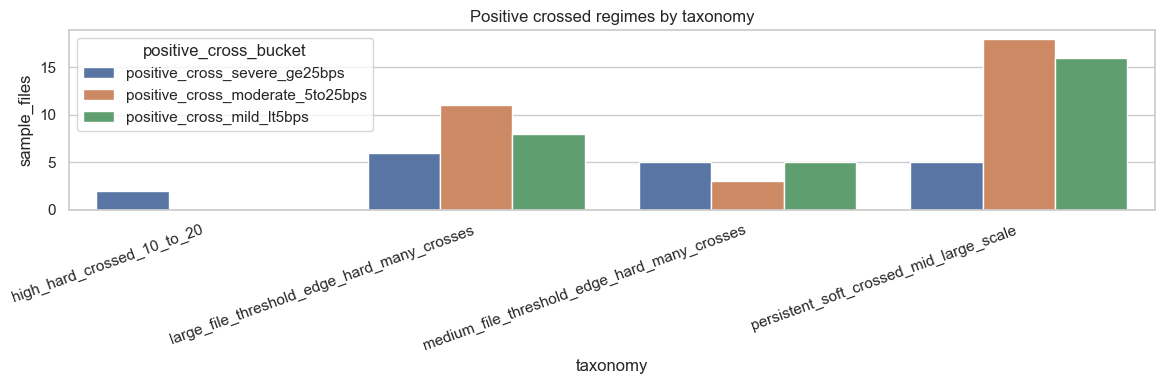

In [8]:
positive_review = load_artifact('positive_cross_review_summary')
display(positive_review)

plt.figure(figsize=(12, 4))
sns.barplot(data=positive_review, x='taxonomy', y='sample_files', hue='positive_cross_bucket')
plt.xticks(rotation=20, ha='right')
plt.title('Positive crossed regimes by taxonomy')
plt.tight_layout()

## Casos Representativos

El `case_index` permite ilustrar el cierre sin volver al universo completo. Aqui miramos solo los casos mas representativos de los buckets bajo revision.


In [9]:
case_index = load_artifact('case_index')
cols = [
    'block', 'taxonomy', 'ticker', 'date', 'severity', 'rows',
    'm.crossed_ratio_pct', 'm.crossed_rows', 'm.ask_integer_pct',
    'm.timestamp_out_of_partition_day'
]
display(case_index.groupby(['block', 'taxonomy']).size().reset_index(name='n').sort_values(['block', 'n'], ascending=[True, False]))
display(case_index.loc[case_index['taxonomy'].isin(review_buckets), cols].head(80))


,block,taxonomy,n
0,forensic,extreme_integerized_100pct_crossed,50
1,issue_examples,high_hard_crossed_5_to_20,50
3,warn_examples,persistent_soft_crossed_mid_thin_scale,48
2,warn_examples,persistent_soft_crossed_mid_large_scale,1
4,warn_examples,utc_rollover_large_day_with_soft_crossed,1


,block,taxonomy,ticker,date,severity,rows,m.crossed_ratio_pct,m.crossed_rows,m.ask_integer_pct,m.timestamp_out_of_partition_day
100,warn_examples,persistent_soft_crossed_mid_large_scale,PRGN,2009-09-21,SOFT_FAIL,14125,0.8,113,0.0,False


## Rollover UTC

La parte temporal queda separada en este cierre porque no debe leerse como el mismo tipo de problema que un crossed economico duro.


,ticker,date,root,severity,rows,m.ts_min_utc,m.ts_max_utc,m.actual_timestamp_dates_utc,warns_primary
0,AMC,2021-01-27,D,SOFT_FAIL,2593648,2021-01-27T09:00:00.025557504+00:00,2021-01-28T00:59:59.989239552+00:00,"[""2021-01-27"", ""2021-01-28""]",crossed_rows_present_but_under_threshold
1,AMC,2021-02-01,D,SOFT_FAIL,2257580,2021-02-01T09:00:00.040036096+00:00,2021-02-02T00:59:59.313345792+00:00,"[""2021-02-01"", ""2021-02-02""]",crossed_rows_present_but_under_threshold
2,ACB,2020-11-06,D,SOFT_FAIL,2160920,2020-11-06T09:00:28.249172736+00:00,2020-11-07T00:59:48.514235136+00:00,"[""2020-11-06"", ""2020-11-07""]",crossed_rows_present_but_under_threshold
3,AMC,2021-02-25,D,SOFT_FAIL,1909456,2021-02-25T09:00:00.327383040+00:00,2021-02-26T00:59:59.841852416+00:00,"[""2021-02-25"", ""2021-02-26""]",crossed_rows_present_but_under_threshold
4,OCGN,2021-02-08,D,SOFT_FAIL,1900762,2021-02-08T09:00:00.022448959+00:00,2021-02-09T00:59:43.200210672+00:00,"[""2021-02-08"", ""2021-02-09""]",crossed_rows_present_but_under_threshold
5,AMC,2021-01-29,D,SOFT_FAIL,1731414,2021-01-29T09:00:00.029973760+00:00,2021-01-30T00:59:59.827098624+00:00,"[""2021-01-29"", ""2021-01-30""]",crossed_rows_present_but_under_threshold
6,BATL,2026-01-26,D,SOFT_FAIL,1687550,2026-01-26T09:00:00.004486990+00:00,2026-01-27T00:59:55.526792661+00:00,"[""2026-01-26"", ""2026-01-27""]",crossed_rows_present_but_under_threshold
7,MLGO,2025-02-21,D,SOFT_FAIL,1570979,2025-02-21T09:00:00.003384897+00:00,2025-02-22T00:59:59.769284478+00:00,"[""2025-02-21"", ""2025-02-22""]",crossed_rows_present_but_under_threshold
8,SNDL,2021-02-11,D,SOFT_FAIL,1566019,2021-02-11T09:00:00.014599372+00:00,2021-02-12T00:59:54.898223573+00:00,"[""2021-02-11"", ""2021-02-12""]",crossed_rows_present_but_under_threshold
9,VERO,2026-01-16,D,SOFT_FAIL,1416548,2026-01-16T09:00:00.001119602+00:00,2026-01-17T00:59:59.975933219+00:00,"[""2026-01-16"", ""2026-01-17""]",crossed_rows_present_but_under_threshold


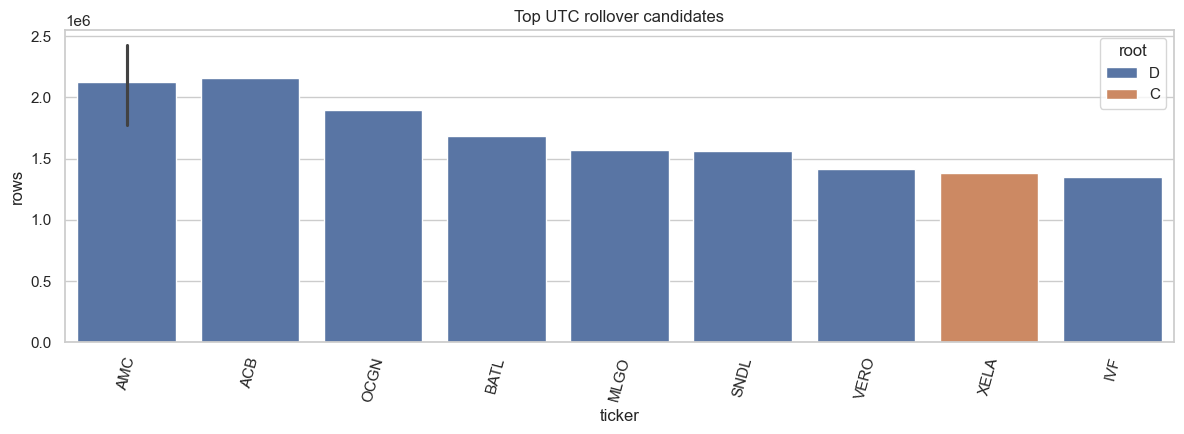

In [10]:
timestamp_view = load_artifact('timestamp_view')
display(timestamp_view.head(20))

if not timestamp_view.empty:
    top_ts = timestamp_view.head(12).copy()
    fig, ax = plt.subplots(figsize=(12, 4.5))
    sns.barplot(data=top_ts, x='ticker', y='rows', hue='root', ax=ax)
    ax.set_title('Top UTC rollover candidates')
    ax.tick_params(axis='x', rotation=75)
    plt.tight_layout()


## Politica Good Review Bad

Esta politica no intenta decidir file a file de forma ciega. Sirve para cerrar la auditoria por familias y dejar una regla reproducible para el residuo.

Regla:

- `good`: residual leve, estable o puramente temporal
- `review`: mezcla real de regimenes `mild/moderate`, o cola severa no dominante
- `bad`: cuando el residual con `ask > 0` sobrevive como severo o estructural


,bucket,decision,reason,files,pct
0,clean_pass_or_other,good,familia base limpia o sin evidencia economica relevante,4361934,45.793275
1,soft_crossed_micro_noise,good,micro-ruido soft,1924034,20.199255
2,persistent_soft_crossed_low,good,crossed leve y estable,887600,9.318369
3,utc_rollover_large_day_clean,good,fenomeno temporal sin fallo economico duro,542446,5.694809
4,large_file_threshold_edge_hard_many_crosses,review,mezcla mild/moderate/severe; bucket heterogeneo,50288,0.527943
5,persistent_soft_crossed_mid_large_scale,review,grueso mild/moderate con cola severe,47076,0.494222
6,medium_file_threshold_edge_hard_many_crosses,bad,residuo ask>0 mezclado con cola severa fuerte,85963,0.902473
7,high_hard_crossed_10_to_20,bad,cuando sobrevive ask>0 lo hace como severe,101549,1.066101


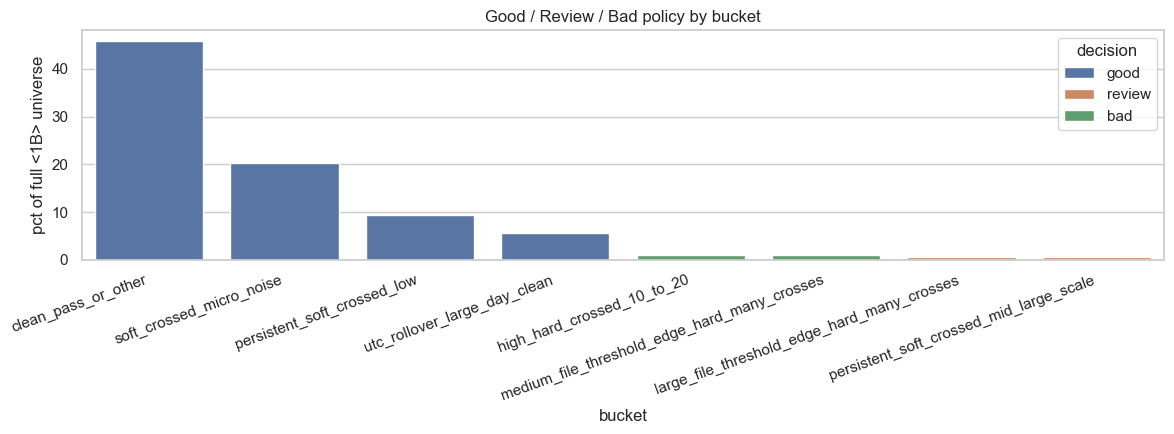

In [11]:
taxonomy = load_artifact('taxonomy_summary').copy()
positive_review = load_artifact('positive_cross_review_summary').copy()

policy_rows = [
    {'bucket': 'clean_pass_or_other', 'decision': 'good', 'reason': 'familia base limpia o sin evidencia economica relevante'},
    {'bucket': 'soft_crossed_micro_noise', 'decision': 'good', 'reason': 'micro-ruido soft'},
    {'bucket': 'persistent_soft_crossed_low', 'decision': 'good', 'reason': 'crossed leve y estable'},
    {'bucket': 'utc_rollover_large_day_clean', 'decision': 'good', 'reason': 'fenomeno temporal sin fallo economico duro'},
    {'bucket': 'large_file_threshold_edge_hard_many_crosses', 'decision': 'review', 'reason': 'mezcla mild/moderate/severe; bucket heterogeneo'},
    {'bucket': 'persistent_soft_crossed_mid_large_scale', 'decision': 'review', 'reason': 'grueso mild/moderate con cola severe'},
    {'bucket': 'medium_file_threshold_edge_hard_many_crosses', 'decision': 'bad', 'reason': 'residuo ask>0 mezclado con cola severa fuerte'},
    {'bucket': 'high_hard_crossed_10_to_20', 'decision': 'bad', 'reason': 'cuando sobrevive ask>0 lo hace como severe'},
]
policy_df = pd.DataFrame(policy_rows)
policy_df = policy_df.merge(taxonomy[['taxonomy','files','pct']], left_on='bucket', right_on='taxonomy', how='left').drop(columns=['taxonomy'])
display(policy_df)

plot_df = policy_df.dropna(subset=['pct']).copy()
order = plot_df.sort_values('pct', ascending=False)['bucket']
plt.figure(figsize=(12, 4.5))
sns.barplot(data=plot_df, x='bucket', y='pct', hue='decision', order=order)
plt.xticks(rotation=20, ha='right')
plt.title('Good / Review / Bad policy by bucket')
plt.ylabel('pct of full <1B> universe')
plt.tight_layout()

## Conclusion Operativa

Conclusion final de cierre:

- `quotes <1B>` no presenta senales de corrupcion masiva del dataset
- la mayor parte del universo cae en `clean_pass_or_other` o en `soft_crossed_micro_noise`
- el residuo principal se concentra en familias acotadas y ya interpretables: `soft crossed` persistente, borde de umbral hard y rollover UTC en dias grandes
- muchos `hard fails` top quedan exactamente en el borde `5.0%`, lo que apunta a comportamiento de regla mas que a caos arbitrario
- muchos `warns` top caen exactamente en `0.8%`, lo que refuerza la idea de familia mecanica estable y no de ruptura masiva
- los extremos verdaderamente severos existen, pero ya quedan aislados y con peso pequeno en el universo total

Decision de cierre provisional:

- considerar operativamente sana la mayor parte del universo auditado
- aceptar como residuo esperable el micro-ruido soft y el rollover UTC limpio
- mantener bajo revision puntual los buckets `persistent_soft_crossed_mid_large_scale`, `large_file_threshold_edge_hard_many_crosses`, `medium_file_threshold_edge_hard_many_crosses` y `high_hard_crossed_10_to_20`
- no seguir refinando taxonomia salvo que una revision economica de esos buckets lo justifique


## Inspector Final De Casos

Inspector visual final para navegar por los cuatro buckets que siguen importando, separados por regimen de crossed positivo.

Reglas:

- `mild`: `< 5 bps`
- `moderate`: `5-25 bps`
- `severe`: `>= 25 bps`


In [12]:
positive_cases = load_artifact('positive_cross_review_cases').copy()
focus_taxonomies = [
    'large_file_threshold_edge_hard_many_crosses',
    'persistent_soft_crossed_mid_large_scale',
    'medium_file_threshold_edge_hard_many_crosses',
    'high_hard_crossed_10_to_20',
]
positive_cases = positive_cases[positive_cases['taxonomy'].isin(focus_taxonomies)].copy()
positive_cases = positive_cases[pd.to_numeric(positive_cases['crossed_rows_ask_positive'], errors='coerce').fillna(0) > 0].copy()
positive_cases['date_str'] = pd.to_datetime(positive_cases['date'], errors='coerce').dt.strftime('%Y-%m-%d')
positive_cases['case_label'] = (
    positive_cases['ticker'].astype(str)
    + ' | ' + positive_cases['date_str'].astype(str)
    + ' | ' + positive_cases['positive_cross_bucket'].astype(str)
    + ' | med=' + positive_cases['cross_rel_bps_median_ask_positive'].round(2).astype(str) + ' bps'
    + ' | +' + positive_cases['crossed_rows_ask_positive'].astype(int).astype(str)
)
positive_cases = positive_cases.sort_values(
    ['taxonomy', 'positive_cross_bucket', 'cross_rel_bps_median_ask_positive', 'crossed_rows_ask_positive'],
    ascending=[True, True, False, False],
).reset_index(drop=True)

TAXONOMY_LABELS = {tax: f"{tax} ({int((positive_cases['taxonomy'] == tax).sum())} casos)" for tax in focus_taxonomies if tax in set(positive_cases['taxonomy'])}
BUCKET_LABELS = {
    'positive_cross_mild_lt5bps': 'mild <5 bps',
    'positive_cross_moderate_5to25bps': 'moderate 5-25 bps',
    'positive_cross_severe_ge25bps': 'severe >=25 bps',
}

taxonomy_dd = widgets.Dropdown(options=[(label, tax) for tax, label in TAXONOMY_LABELS.items()], description='taxonomy', layout=widgets.Layout(width='420px'))
bucket_dd = widgets.Dropdown(description='regime', layout=widgets.Layout(width='240px'))
case_dd = widgets.Dropdown(description='file', layout=widgets.Layout(width='900px'))
window_slider = widgets.IntSlider(value=600, min=100, max=5000, step=100, description='window', continuous_update=False, layout=widgets.Layout(width='420px'))
index_toggle = widgets.Checkbox(value=False, description='usar indice x', indent=False)
summary_out = widgets.Output()
plot_out = widgets.Output()

def _bucket_options(taxonomy: str):
    sub = positive_cases.loc[positive_cases['taxonomy'].eq(taxonomy)].copy()
    order = ['positive_cross_mild_lt5bps','positive_cross_moderate_5to25bps','positive_cross_severe_ge25bps']
    return [(f"{BUCKET_LABELS[b]} ({int(sub['positive_cross_bucket'].eq(b).sum())})", b) for b in order if int(sub['positive_cross_bucket'].eq(b).sum()) > 0]

def _case_options(taxonomy: str, bucket: str):
    sub = positive_cases.loc[positive_cases['taxonomy'].eq(taxonomy) & positive_cases['positive_cross_bucket'].eq(bucket)].copy()
    return [(row['case_label'], int(idx)) for idx, row in sub.iterrows()]

def _refresh_bucket(*_):
    opts = _bucket_options(taxonomy_dd.value)
    bucket_dd.options = opts
    if opts:
        bucket_dd.value = opts[0][1]

def _refresh_case(*_):
    opts = _case_options(taxonomy_dd.value, bucket_dd.value)
    case_dd.options = opts
    if opts:
        case_dd.value = opts[0][1]

_is_initializing = True

taxonomy_dd.observe(_refresh_bucket, names='value')
bucket_dd.observe(_refresh_case, names='value')
_refresh_bucket()
_refresh_case()

def _load_case_frame(file_path: str) -> pd.DataFrame:
    df = pd.read_parquet(file_path, columns=['timestamp','bid_price','ask_price','bid_size','ask_size','bid_exchange','ask_exchange'])
    df['bid_price'] = pd.to_numeric(df['bid_price'], errors='coerce')
    df['ask_price'] = pd.to_numeric(df['ask_price'], errors='coerce')
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['ts_ny'] = pd.to_datetime(df['timestamp'], unit='ns', utc=True, errors='coerce').dt.tz_convert('America/New_York')
    df['cross_positive'] = df['bid_price'].gt(df['ask_price']) & df['ask_price'].gt(0)
    df['gap'] = df['bid_price'] - df['ask_price']
    df['mid'] = (df['bid_price'] + df['ask_price']) / 2.0
    df['gap_bps'] = np.where(df['mid'] > 0, df['gap'] / df['mid'] * 10000.0, np.nan)
    return df

def _render(*_):
    if _is_initializing:
        return
    if case_dd.value is None:
        return
    row = positive_cases.loc[int(case_dd.value)].copy()
    df = _load_case_frame(row['file'])
    cross_idx = np.flatnonzero(df['cross_positive'].fillna(False).to_numpy())
    if len(cross_idx) == 0:
        with summary_out:
            clear_output(wait=True)
            display(Markdown('`No hay filas crossed positivas en este file.`'))
        with plot_out:
            clear_output(wait=True)
        return
    start = max(int(cross_idx.min()) - window_slider.value, 0)
    end = min(int(cross_idx.max()) + window_slider.value + 1, len(df))
    view = df.iloc[start:end].copy()
    if len(view) > 4000:
        step = max(int(np.ceil(len(view) / 4000)), 1)
        sampled = view.iloc[::step].copy()
        crossed_view = view.loc[view['cross_positive']].copy()
        view = pd.concat([sampled, crossed_view], ignore_index=False).sort_index().loc[lambda x: ~x.index.duplicated(keep='first')].copy()
    x = np.arange(len(view)) if index_toggle.value else view['ts_ny']
    crossed_view = view.loc[view['cross_positive']].copy()
    x_cross = np.flatnonzero(view['cross_positive'].to_numpy()) if index_toggle.value else crossed_view['ts_ny']
    summary_df = pd.DataFrame([{
        'taxonomy': row['taxonomy'],
        'positive_cross_bucket': row['positive_cross_bucket'],
        'ticker': row['ticker'],
        'date': row['date_str'],
        'rows_file': int(row['rows']),
        'crossed_ratio_pct': float(row['m.crossed_ratio_pct']),
        'crossed_rows_raw': int(row['crossed_rows_raw']),
        'crossed_rows_ask_zero': int(row['crossed_rows_ask_zero']),
        'crossed_rows_ask_positive': int(row['crossed_rows_ask_positive']),
        'ask_zero_share_pct': float(row['crossed_ask_zero_share_pct']),
        'ask_positive_share_pct': float(row['crossed_ask_positive_share_pct']),
        'median_bps_ask_positive': float(row['cross_rel_bps_median_ask_positive']),
        'p90_bps_ask_positive': float(row['cross_rel_bps_p90_ask_positive']),
        'file': row['file'],
    }])
    with summary_out:
        clear_output(wait=True)
        display(summary_df)
    with plot_out:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1.2]})
        axes[0].plot(x, view['bid_price'], color='#0f766e', linewidth=1.2, label='bid_price')
        axes[0].plot(x, view['ask_price'], color='#b91c1c', linewidth=1.2, label='ask_price')
        axes[0].scatter(x_cross, crossed_view['bid_price'], color='#f59e0b', s=18, alpha=0.9, label='crossed bid > ask > 0')
        axes[0].scatter(x_cross, crossed_view['ask_price'], color='#7c3aed', s=18, alpha=0.6, label='ask en crossed')
        axes[0].set_title(f"{row['ticker']} | {row['date_str']} | {BUCKET_LABELS[row['positive_cross_bucket']]} | ventana raw")
        axes[0].set_ylabel('price')
        axes[0].legend(loc='upper right', ncol=2, frameon=True)
        axes[1].scatter(x_cross, crossed_view['gap_bps'], color='#dc2626', s=18, alpha=0.85)
        axes[1].axhline(5.0, color='#2563eb', linestyle='--', linewidth=1.0, label='5 bps')
        axes[1].axhline(25.0, color='#111827', linestyle='--', linewidth=1.0, label='25 bps')
        axes[1].fill_between(x_cross, crossed_view['gap_bps'], 0, color='#fca5a5', alpha=0.25)
        axes[1].set_ylabel('gap bps')
        axes[1].set_xlabel('row index en ventana' if index_toggle.value else 'timestamp NY')
        axes[1].legend(loc='upper right', frameon=True)
        axes[1].set_title('Severidad del crossed positivo')
        plt.tight_layout()
        plt.show()

for w in [taxonomy_dd, bucket_dd, case_dd, window_slider, index_toggle]:
    w.observe(_render, names='value')

_is_initializing = False

display(widgets.VBox([
    widgets.HBox([taxonomy_dd, bucket_dd]),
    case_dd,
    widgets.HBox([window_slider, index_toggle]),
    summary_out,
    plot_out,
]))
_render()

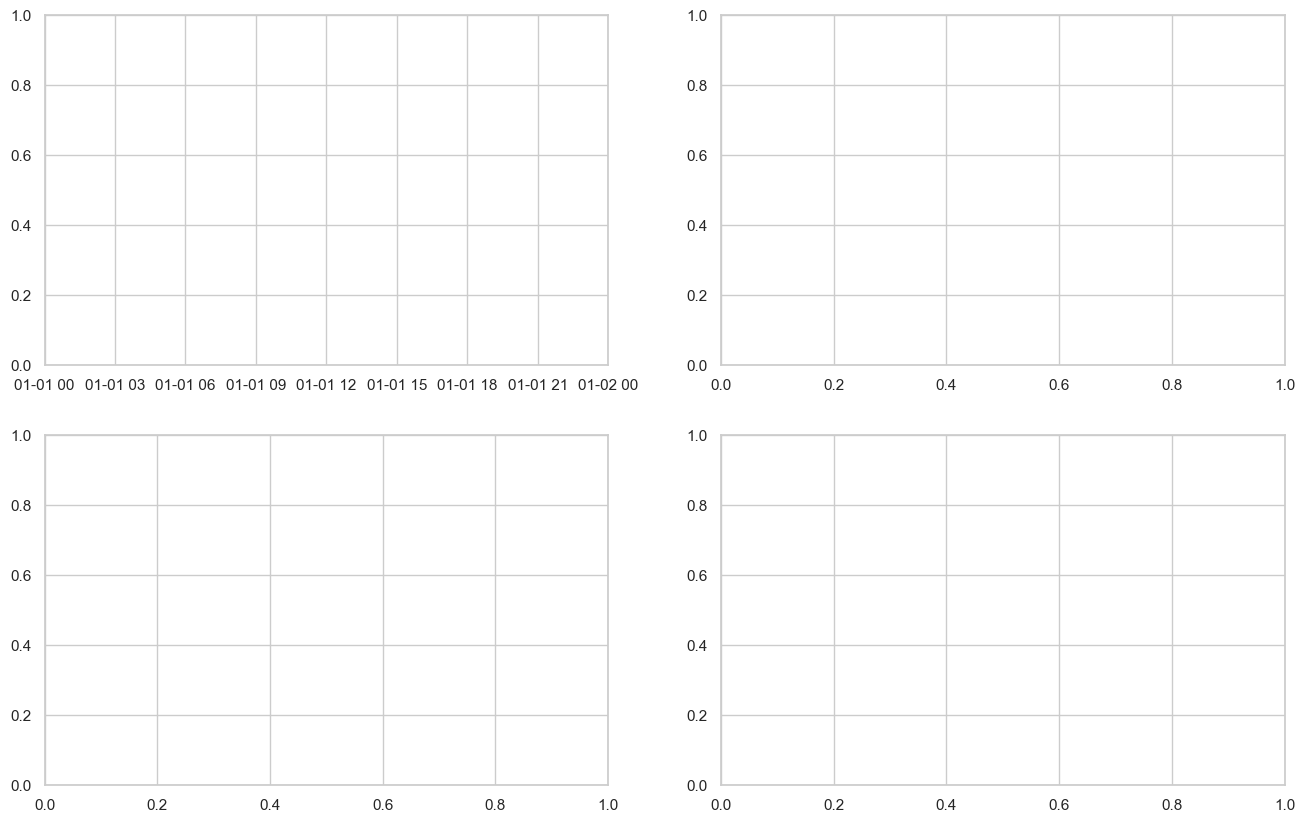

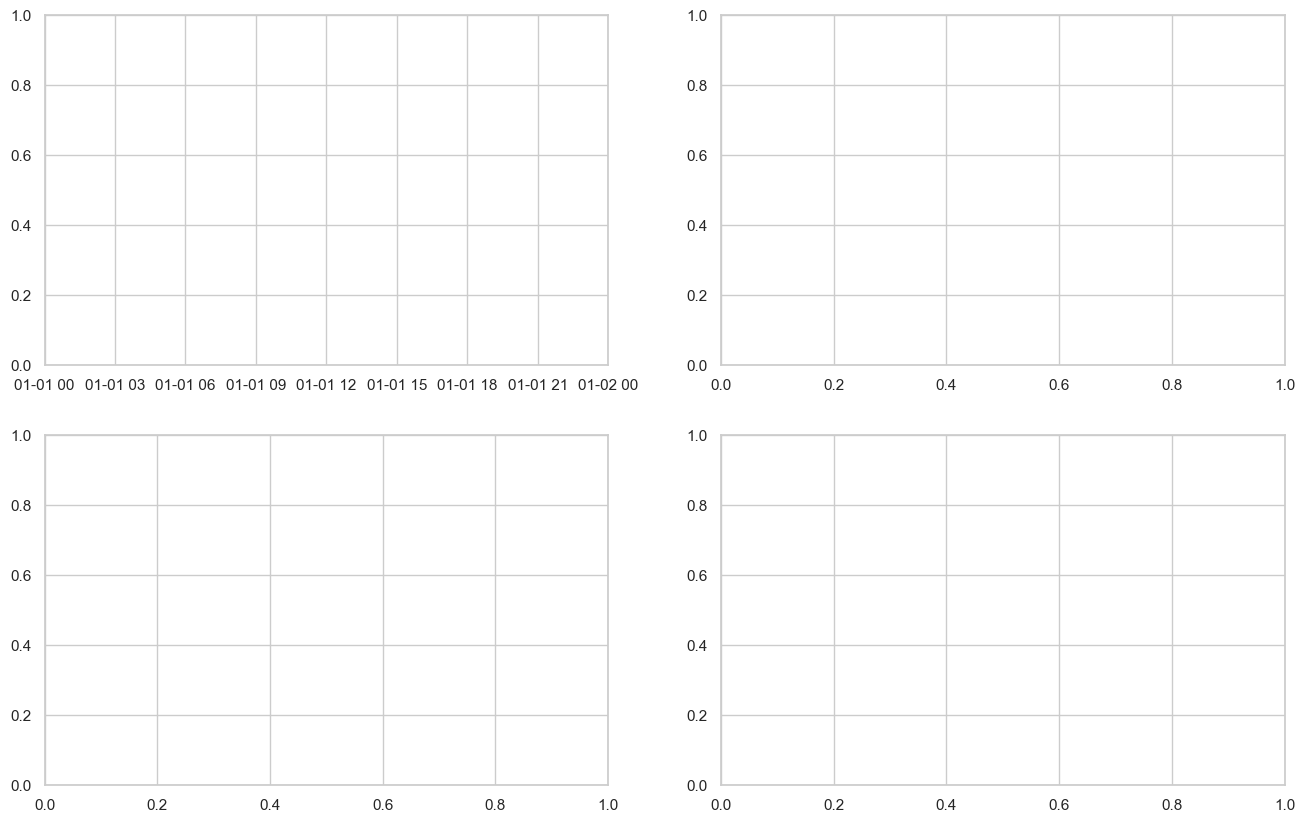

In [13]:

import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.inspection.quotes.quotes_case_panel as quotes_case_panel
importlib.reload(quotes_case_panel)

from scripts.inspection.quotes.quotes_case_panel import build_quotes_case_selector

display(build_quotes_case_selector("review"))

#  Y para empezar por el bloque duro:

display(build_quotes_case_selector("bad"))
